## Check CAMS data

In [1]:
# import 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys
from utils.utilities import find_best_grid_point, get_station_coords,form_xdate, get_anomalies
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import mplotutils as mpu

from plotting import tol_colors # color schemes from https://personal.sron.nl/~pault/

#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

# File path
data_path = "../data/"

#save figures in...
dir_save = './output/cams/'
fig_format = 'png'

In [2]:
## Read all data
%autoreload 2
from analyses.input.read_wdc_data import AvailableData, create_data_reader


# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")


['CO2', 'CO2_flask', 'CO', 'CO_flask', 'CO_2002-2006', 'CH4', 'CH4_flask', 'O3', 'aerosols_2015', 'aerosols', 'other_gases_ebas', 'other_gases_wdc', 'meteo']
Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


In [3]:
# Read in CAMS data of the best selected grid
cams_best_grid_unmerged = xr.open_dataset(f"{data_path}/level3/cams/cams_best_grid_MKN.nc")
# the merged best-grid dataset contains the cams inversion data merged for the two periods of different horizontal resolution 
cams_best_grid = xr.open_dataset(f"{data_path}/level3//cams/cams_best_grid_merged_MKN.nc") 

In [4]:
## resample observations
# remove unnecessary variables for simplication
variables_to_keep = ["time", "dataset", "value", "value_unc", "unit", "species"]
ds_all_simple = ds_all.drop_vars(set(ds_all.variables) - set(variables_to_keep))


# Resample only time-dependent variables
time_dependent_variables = [
    var for var in ds_all_simple.data_vars if "time" in ds_all_simple[var].dims
]
non_time_dependent_variables = [
    var
    for var in ds_all_simple.data_vars
    if var not in time_dependent_variables or not "time"
]

ds_all_3h = (
    ds_all_simple[time_dependent_variables].resample(time="3h").mean(keep_attrs=True)
)
ds_all_6h = (
    ds_all_simple[time_dependent_variables].resample(time="6h").mean(keep_attrs=True)
)
# add non-time dependent variables again
for var in non_time_dependent_variables:
    ds_all_3h[var] = ds_all_simple[var]
    ds_all_6h[var] = ds_all_simple[var]

##### Check the selected CAMS grids
This only works when the full CAMS data was loaded. 
If you do not have locally stored cams data (see analyses_stebysteb.ipynb), skip this and go to the next section

In [5]:
# Read all full cams datasets
dir_data_cams = r"../data/level3/cams"
cams_invgg_co2_A = xr.open_dataset(dir_data_cams + r"/cams_invGG_co2_202001_202306_MKN.nc") #first period (lower resolution)
cams_invgg_co2_B = xr.open_dataset(dir_data_cams + r"/cams_invGG_co2_202307_202309_MKN.nc")
cams_invgg_ch4_A = xr.open_dataset(dir_data_cams + r"/cams_invGG_ch4_202001_202112_MKN.nc")
cams_invgg_ch4_B = xr.open_dataset(dir_data_cams + r"/cams_invGG_ch4_202201_202212_MKN.nc")
cams_eac4 = xr.open_dataset(dir_data_cams + r"/cams_eac4_2003_2023_MKN.nc")
cams_egg4 = xr.open_dataset(dir_data_cams + r"/cams_egg4_2003_2020_MKN.nc")

cams_gfas = xr.open_dataset(dir_data_cams + r"/cams_gfas_2020_2023.nc")

In [6]:
cams_invgg_co2_A

<xarray.Dataset>
Dimensions:                           (latitude: 5, longitude: 4, level: 79,
                                       time: 10216, hlevel: 80)
Coordinates:
  * latitude                          (latitude) float64 -2.535 -1.268 ... 2.535
  * longitude                         (longitude) float64 32.5 35.0 37.5 40.0
  * level                             (level) float64 0.0 1.0 2.0 ... 77.0 78.0
  * time                              (time) datetime64[ns] 2020-01-01 ... 20...
Dimensions without coordinates: hlevel
Data variables:
    CO2                               (time, level, latitude, longitude) float32 ...
    height_above_reference_ellipsoid  (time, hlevel, latitude, longitude) float32 ...
    Psurf                             (time, latitude, longitude) float64 ...
    ap                                (time, hlevel) float64 ...
    bp                                (time, hlevel) float64 ...
Attributes:
    Conventions:  CF-1.6
    title:        Global atmospheric concentrations inferred by atmospheric i...
    institution:  LSCE (CEA/CNRS/UVSQ) - IPSL
    source:       Assimilation of XCO2 retrievals
    history:      2023-10-06 21:48:45 GMT, PYVAR run by p24cheva
    references:   doi:10.1029/2005JD006390, doi:10.5194/gmd-6-783-2013, doi:1...

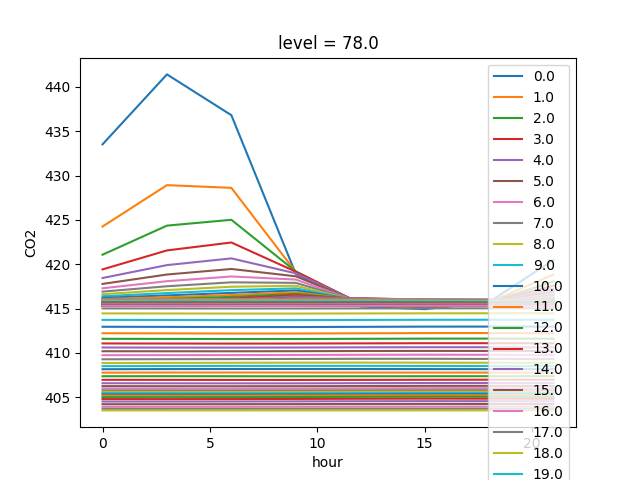

In [10]:
## check diurnal cycle of specific cams product
ds_sel = cams_invgg_co2_A.groupby("time.hour").mean().mean('latitude').mean('longitude')['CO2']
plt.figure()
for l in cams_invgg_co2_A.level:
    ds_sel.sel(level=l).plot(label=l.values)
plt.legend()
plt.show()

#### Check how the best grid point is selected for a specific dataset

KeyError: "not all values found in index 'longitude'. Try setting the `method` keyword argument (example: method='nearest')."

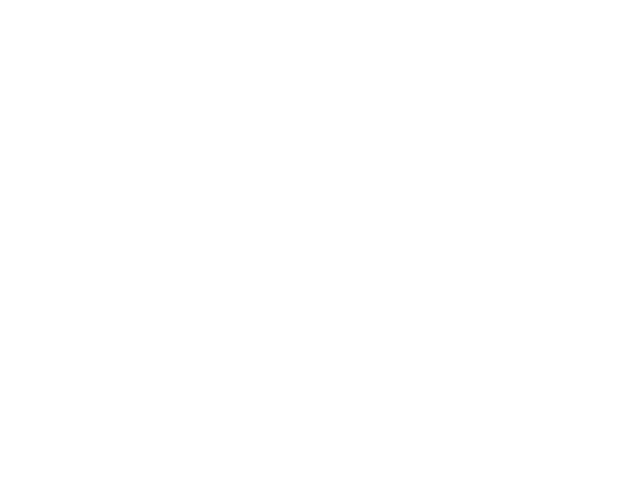

In [12]:
# check correlations for selected cams grid for egg4 data
# For the egg4 data, the best_grid_selection selects a pressure level that does not correspond well!
# We have anyway only 1 year of data, so better don't use the egg4 data for CO2!

from scipy.stats import spearmanr

# which dataset to check
ds_name = 'co2_egg4'
species= 'CO2'

# selected grid
lat_sel = cams_best_grid.sel(dataset=ds_name).latitude.values
lon_sel = cams_best_grid.sel(dataset=ds_name).longitude.values

model_sel = cams_egg4[species].sel(time=slice('2020-01-01','2020-12-31'))
plt.figure()
data = ds_all_3h.sel(dataset=species,time=slice('2020-01-01','2020-12-31')).value
for l in model_sel.level:
    model = model_sel.sel(level=l).sel(longitude=lon_sel,latitude=lat_sel)

    res = spearmanr(data.values, np.array(model.values).squeeze(), nan_policy='omit')
    r = res.statistic
    p = res.pvalue # pvalues are very small, so it is not likely that the correlation is due to chance
    if l.values>850: # if I want to skip some levels in plots
       continue
    else:
        model.plot(alpha=0.6,label=f'{l.values}hPa, r={r:.2f}')
        print(l.values, r, p)
data.plot(label='obs.',alpha=.4,ls=':')
plt.legend()
plt.title(f'{species} correlations obs vs. cams {ds_name} (grid: {lat_sel:.2f}lat, {lon_sel:.2f}lon)')
plt.savefig(f'{dir_save}cams_best_grid_correlations_{species}_{ds_name}.png', #_all_levels.png',
            format=fig_format)


##### check the resolution of a specific CAMS product


In [ ]:
# check the cams inversion ghg data (CO2)
test1= xr.open_dataset(r"C:\Users\leob\Documents\Data_analyses\Data\CAMS\invGG\cams73_latest_co2_conc_satellite_inst_202002.nc")
test2= xr.open_dataset(r"C:\Users\leob\Documents\Data_analyses\Data\CAMS\invGG\cams73_latest_co2_conc_satellite_inst_202306.nc")
test3= xr.open_dataset(r"C:\Users\leob\Documents\Data_analyses\Data\CAMS\invGG\cams73_latest_co2_conc_satellite_inst_202309.nc")
#print the sizes:
test1.dims, test2.dims, test3.dims

# CO2 data has a higher resolution starting in July 2023!

# get the mean longitude and latitude grid spaces
print('before 2023:', test1.longitude.diff('longitude').mean().values, 'lon,', test1.latitude.diff('latitude').mean().values, 'lat,',test1.time.diff('time').mean().values.astype('timedelta64[h]'))
print('June 2023:', test2.longitude.diff('longitude').mean().values, 'lon,', test2.latitude.diff('latitude').mean().values, 'lat,',test2.time.diff('time').mean().values.astype('timedelta64[h]'))
print('Sept 2023:', test3.longitude.diff('longitude').mean().values, 'lon,', test3.latitude.diff('latitude').mean().values, 'lat,',test3.time.diff('time').mean().values.astype('timedelta64[h]'))

In [ ]:
## same fof CH4 data (inversion data)
# check the cams inversion ghg data (CO2)
test1= xr.open_dataset(r"C:\Users\leob\Documents\Data_analyses\Data\CAMS\invGG\cams73_latest_ch4_conc_surface_satellite_inst_202112.nc")
test2= xr.open_dataset(r"C:\Users\leob\Documents\Data_analyses\Data\CAMS\invGG\cams73_latest_ch4_conc_surface_satellite_inst_202201.nc")
#print the sizes:
test1.dims, test2.dims

# Ch4 data has a higher resolution starting in January 2022!

# get the mean longitude and latitude grid spaces
print('before 2022:', test1.longitude.diff('longitude').mean().values, 'lon,', test1.latitude.diff('latitude').mean().values, 'lat,',test1.time.diff('time').mean().values.astype('timedelta64[h]'))
print('Jan 2022:', test2.longitude.diff('longitude').mean().values, 'lon,', test2.latitude.diff('latitude').mean().values, 'lat,',test2.time.diff('time').mean().values.astype('timedelta64[h]'))

In [ ]:
#example figure
#plt.figure()
#test2.mean(dim='time').isel(level=0).CH4.plot()

#### Show which grids are selcted in cams data

<>:97: SyntaxWarning: invalid escape sequence '\c'
<>:97: SyntaxWarning: invalid escape sequence '\c'
C:\Users\leob\AppData\Local\Temp\ipykernel_22892\3433910112.py:97: SyntaxWarning: invalid escape sequence '\c'
  plt.savefig(f'{dir_save}\cams_selected_grids.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')


co2_invgg
co2_invgg2
co2_egg4
ch4_invgg
ch4_invgg2
ch4_egg4
co_eac4
o3_eac4


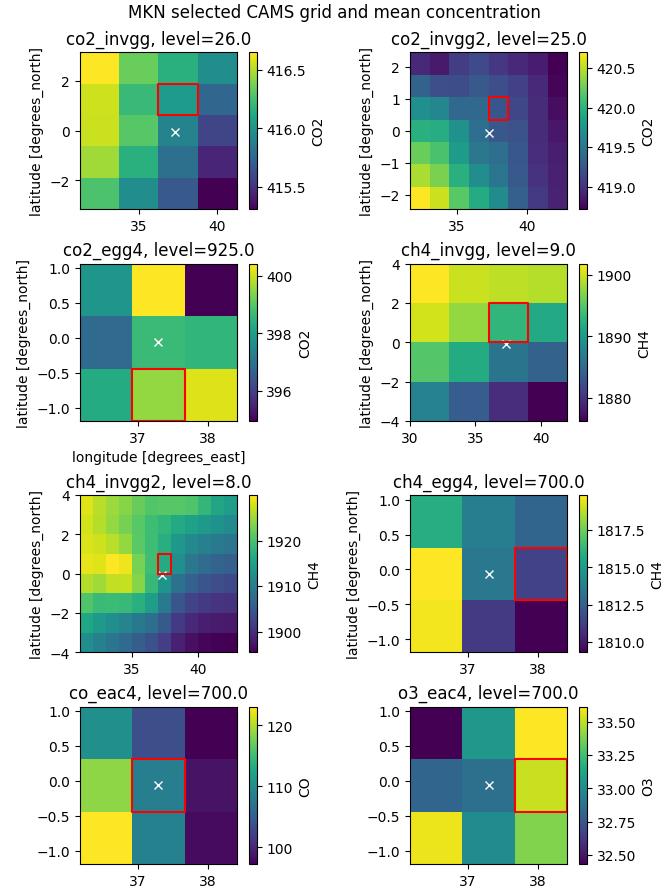

In [13]:
# to obtain pressure at levels for invgg cams data: see https://confluence.ecmwf.int/display/CKB/ERA5%3A+compute+pressure+and+geopotential+on+model+levels%2C+geopotential+height+and+geometric+height

# mkn station:

lat, lon, alt = get_station_coords("MKN")

nbr_plots = len(cams_best_grid_unmerged.dataset)
fig, axs = plt.subplots(
    int(nbr_plots / 2),
    int(nbr_plots / 3),
    figsize=(10, 8),
    layout="constrained",
)

for i, (ds_name, ax) in enumerate(zip(cams_best_grid_unmerged.dataset, axs.flatten())):
    print(ds_name.values)
    # select the cams data
    if ds_name == "co2_invgg":
        cams_sel = cams_invgg_co2_A["CO2"]    
        
    elif ds_name == "co2_invgg2":
        cams_sel = cams_invgg_co2_B["CO2"]

    elif "co2_egg4" in ds_name:
        cams_sel = cams_egg4["CO2"]

    # CH4
    elif "ch4_invgg" in ds_name:
        cams_sel = cams_invgg_ch4_A["CH4"]

    elif "ch4_invgg2" in ds_name:
        cams_sel = cams_invgg_ch4_B["CH4"]

    elif ds_name == "ch4_egg4":
        cams_sel = cams_egg4["CH4"]

    # CO
    elif ds_name == "co_eac4":
        cams_sel = cams_eac4["CO"]

    # O3
    elif ds_name == "o3_eac4":
        cams_sel = cams_eac4["O3"]

    # get time period of cams data
    t1 = cams_sel.time.min().values
    t2 = cams_sel.time.max().values

    # different periods for invgg data, to distinguish between the two periods of different horizontal resolution
    if ds_name == "co2_invgg":
        t2 = np.datetime64("2023-06-30 23:00:00")
    if ds_name == "co2_invgg2":
        t1 = np.datetime64("2023-07-01")

    if ds_name == "ch4_invgg":
        t2 = np.datetime64("2021-12-31 23:00:00")
    if ds_name == "ch4_invgg2":
        t1 = np.datetime64("2022-01-01")

    # select only the period where we have data
    cams_selected_period = cams_sel.sel(time=slice(t1, t2),drop=True)
    cams_selected_period = cams_selected_period.where(np.isnan(cams_selected_period)==False,drop=True)

    # selected grid:
    cams_lev = cams_best_grid_unmerged.sel(dataset=ds_name).level.values
    cams_lat = cams_best_grid_unmerged.sel(dataset=ds_name).latitude.values
    cams_lon = cams_best_grid_unmerged.sel(dataset=ds_name).longitude.values
    #plot the selected cams data
    cams_selected_period.sel(level=cams_lev).mean(dim="time").plot(ax=ax,rasterized=True)

    ax.plot(lon, lat, marker="x", color="w")  # mt. kenya station

    # Draw a red rectangle around the selected grid cell
    dy = np.unique(np.diff(cams_selected_period.latitude))
    dx = np.unique(np.diff(cams_selected_period.longitude))
    lat_min, lat_max = cams_lat - dy / 2, cams_lat + dy / 2
    lon_min, lon_max = cams_lon - dx / 2, cams_lon + dx / 2
    ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        color="red",
    )
    # plot the reactangle using matplotlib.patches
    #from matplotlib.patches import Rectangle
    #ax.add_patch(plt.Rectangle((lon_min, lat_min), dx, dy, edgecolor='red', facecolor='none', lw=2, transform=ccrs.PlateCarree()))

    ax.set_title(f"{ds_name.values}, level={str(cams_lev)}")
    if i != 2:
        ax.set_xlabel("")  # xlabel only in the bottom
    if i == nbr_plots - 1 or i == nbr_plots - 2:
        ax.set_ylabel("")  # ylabel only on the left

plt.suptitle("MKN selected CAMS grid and mean concentration")
plt.setp(axs, box_aspect=1)  # get quadratic plots
mpu.set_map_layout(axs)  # better spaces between map-figures

plt.savefig(f'{dir_save}\cams_selected_grids.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')
plt.show()

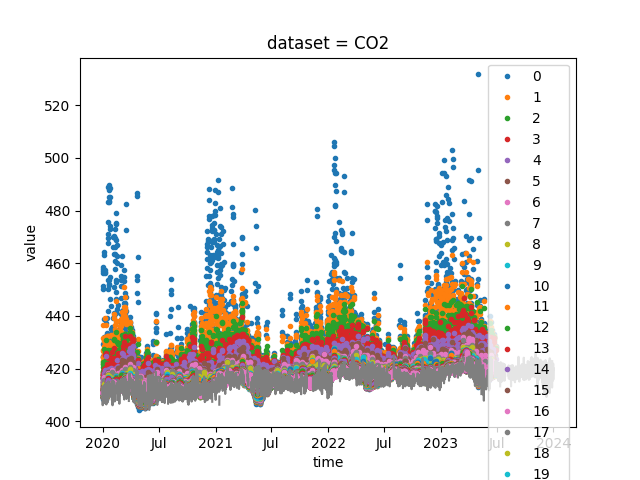

In [33]:
plt.figure()
for l in np.arange(0,27): #plot different levels
    cams_invgg_co2_A.sel(latitude=1,longitude=37.5,method='nearest',level=l)['CO2'].plot(ls='',marker='.',label=l)

ds_all_3h.sel(time=slice(tsel1, tsel2),dataset='CO2').value.plot(label='Obs.')
plt.legend()
plt.show()  

In [36]:
p = cams_invgg_co2_A['Ai']/100 + cams_invgg_co2_A['Bi'] * cams_invgg_co2_A['Psurf']

KeyError: "No variable named 'Ai'. Variables on the dataset include ['latitude', 'longitude', 'level', 'time', 'CO2', 'height_above_reference_ellipsoid', 'Psurf', 'ap', 'bp']"

In [37]:
cams_invgg_co2_A

<xarray.Dataset>
Dimensions:                           (latitude: 5, longitude: 4, level: 79,
                                       time: 10216, hlevel: 80)
Coordinates:
  * latitude                          (latitude) float64 -2.535 -1.268 ... 2.535
  * longitude                         (longitude) float64 32.5 35.0 37.5 40.0
  * level                             (level) float64 0.0 1.0 2.0 ... 77.0 78.0
  * time                              (time) datetime64[ns] 2020-01-01 ... 20...
Dimensions without coordinates: hlevel
Data variables:
    CO2                               (time, level, latitude, longitude) float32 ...
    height_above_reference_ellipsoid  (time, hlevel, latitude, longitude) float32 ...
    Psurf                             (time, latitude, longitude) float64 ...
    ap                                (time, hlevel) float64 ...
    bp                                (time, hlevel) float64 ...
Attributes:
    Conventions:  CF-1.6
    title:        Global atmospheric concentrations inferred by atmospheric i...
    institution:  LSCE (CEA/CNRS/UVSQ) - IPSL
    source:       Assimilation of XCO2 retrievals
    history:      2023-10-06 21:48:45 GMT, PYVAR run by p24cheva
    references:   doi:10.1029/2005JD006390, doi:10.5194/gmd-6-783-2013, doi:1...

### Compare CAMS with measurement data at MKN

In [14]:
###### --- FOR ALL comparison FIGURES --- #####
## Select the time period and species to plot


tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

sel_species = ds_all.species
unique_species = np.unique(sel_species)

species_sel = unique_species

# species_sel = ["CO2", "CO"]



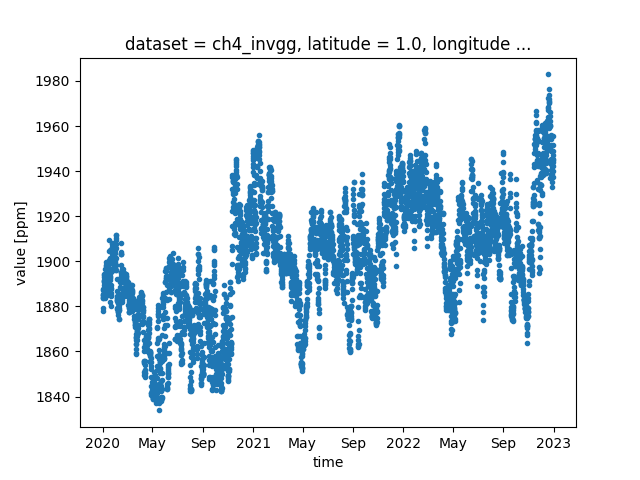

In [15]:
plt.figure()
cams_best_grid.sel(dataset='ch4_invgg').value.plot(ls='-',marker='.')
plt.show()

In [ ]:
## Check the correlation between cams and measurements for a single species
s = 'CO'
ds_dataset = 'CO'
cams_dataset = 'co_eac4'
cams = cams_best_grid.sel(dataset=cams_dataset, time=slice(tsel1, tsel2)).resample(time='1D').mean()["value"]
ds_sel = ds_all_3h.sel(time=slice(tsel1, tsel2)).sel(dataset=ds_dataset).resample(time='1D').mean()["value"]
fig, axs = plt.subplots()
axs.scatter(ds_sel,cams,alpha=0.8)
axs.set_xlabel('in-situ CO daily median')
axs.set_ylabel('CAMS EAC4 CO daily means')
plt.setp(axs, box_aspect=1,aspect='equal')
ds_max_lim = ds_sel.max() +10
plt.plot([0,ds_max_lim],[0,ds_max_lim],c='k',lw=0.5,zorder=0)
axs.set_xlim([0,ds_max_lim])
axs.set_ylim([0,ds_max_lim])
plt.show()

In [ ]:
## Remove cams products that I don't want to plot
cams_best_grid = cams_best_grid.drop_sel(dataset=["co2_egg4","ch4_egg4"])

In [ ]:
## plot cams versus observations
alpha = 0.7
ms = 8
species_sel = [ 'CO2', 'CH4', 'CO', 'O3']

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    if s == "CH4":
        ds = ds_all_6h  # ch4 has 6h resolution
    else:
        ds = ds_all_3h

    # OR: use hourly observations
    # ds = ds_all

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
    # select cams datasets that exist for this species
    cams_datasets_sel = [
        cams_sel
        for cams_sel in cams_best_grid.dataset.values
        if f"{s.lower()}_" in cams_sel
    ]
    cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

    # if cams_datasets_sel[0] == 'ch4_invgg':
    #     ## WORKAROUND for presentation figure (new ch4 data not working yet!?)
    #     # skip ch4 data (cams_best_grid.sel(dataset = ch4_invgg) ) after 2021
    #     cams = cams.sel(time=slice(tsel1, "2021-12-31"))


    # function to plot each subplot
    def plot_data(ds, label):
        if "flask" in str(ds.dataset.values):
            m = "."
            l = ""
        else:
            m = "."
            l = "-"
        ds.plot(
            ax=ax,
            ls=l,
            marker=m,
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"{label} {str(ds.dataset.values)}",
        )

    # plot obs
    if len(ds_sel.dataset) > 1:  # several obs datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in ds_sel.dataset
            if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
        ]
        for ds_i in ds_sel.sel(dataset=variables_to_keep).dataset:
            plot_data(ds_sel.sel(dataset=ds_i.values)["value"], "obs")
    else:
        plot_data(ds_sel.sel(dataset=s)["value"], "obs")

    # plot cams
    if len(cams.dataset) > 1:  # several cams datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in cams.dataset
            if cams.sel(dataset=spec)["value"].isnull().all() == False
        ]
        for cams_i in cams.sel(dataset=variables_to_keep).dataset:
            plot_data(cams.sel(dataset=cams_i)["value"], "cams")
    else:
        plot_data(cams.isel(dataset=0)["value"], "cams")

    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title("")
    ax.grid()
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()

fig_format = 'png'
plt.savefig(f'{dir_save}\MKN_gaw_cams.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')
plt.show()

In [ ]:
## plot bias between cams and observations
def root_mean_squared_error(x, y):
    return np.sqrt(((x - y) ** 2).mean(dim="time"))


def mean_bias(x, y):
    return (x).mean(dim="time") - (y).mean(dim="time")


alpha = 0.7
ms = 8

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    # select CAMS for which I want to show the bias
    if s == "CO2":
        cams_dataset = "co2_invgg"  # "co2_egg4"
    elif s == "CH4":
        cams_dataset = "ch4_invgg"  # "ch4_egg4"
    elif s == "CO":
        cams_dataset = "co_eac4"
    elif s == "O3":
        cams_dataset = "o3_eac4"

    # select obs, ch4_invgg has 6h resolution
    if cams_dataset == "ch4_invgg":
        ds = ds_all_6h  # ch4 has 6h resolution
    else:
        ds = ds_all_3h

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)

    # function to plot each subplot
    def plot_bias(x):
        x.plot(
            ax=ax,
            ls="-",
            marker=".",
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"cams-obs",
        )

    # plot bias
    cams = cams_best_grid.sel(dataset=cams_dataset, time=slice(tsel1, tsel2))
    if len(ds_sel.dataset) > 1:  # several datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in ds_sel.dataset
            if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
        ]
        for ii in ds_sel.sel(dataset=variables_to_keep).dataset:
            plot_bias(cams["value"] - ds_sel.sel(dataset=ii)["value"])
    else:
        plot_bias(cams["value"] - ds_sel.sel(dataset=s)["value"])

    mbias = mean_bias(cams["value"], ds_sel.sel(dataset=s)["value"]).values
    rmse = root_mean_squared_error(cams["value"], ds_sel.sel(dataset=s)["value"]).values
    ax.text(
        1.05,
        0.2,
        f"Mean bias = {mbias:.2f} {ds_sel.unit[0].values} \nRMSE = {rmse:.2f} {ds_sel.unit[0].values}",
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize="small",
    )

    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title(f"CAMS: {cams_dataset}")
    # ax.legend()
plt.suptitle("Bias (CAMS-obs)")
plt.tight_layout()

In [ ]:
## Figure for single species
data_sel = "CO2"
cams_dataset = "co2_invgg"

obs = ds_all_3h.sel(time=slice(tsel1, tsel2), dataset=data_sel, drop=True)
cams = cams_best_grid.sel(dataset=cams_dataset, time=slice(tsel1, tsel2))

fig, ax = plt.subplots(figsize=(6, 4))
alpha = 0.8
ms = 8

pl_obs = obs["value"].plot(
    marker=".",
    ls="-",
    label="Observations (3h mean)",
    alpha=alpha,
    markeredgewidth=0,
    markersize=ms,
)
pl_cams = cams["value"].plot(
    marker=".", ls="-", label="CAMS", alpha=alpha, markeredgewidth=0, markersize=ms
)
mw_days = 5  # moving window days
mw = 3 * 8 * mw_days  #  moving window
# cams_best.rolling(time=mw,center=True,min_periods=mw/2).mean().plot(ls='-',c='k')#c=pl_cams[0].get_color())
# obs3h.to_xarray().rolling(time=mw,center=True,min_periods=mw/2).mean().plot(ls='-',c=pl_obs[0].get_color())
plt.ylabel("CO2 (ppm)")
plt.xlabel("Time")
plt.legend()
plt.title("Mt. Kenya GAW station: \nCO2 observations and CAMS Model data")
form_xdate(ax, "Y", 1, "")
fig_format = "png"
plt.tight_layout()
# plt.savefig(fr'.\analyses\MKN_co2_gaw_cams_inv.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')

# plt.savefig(f'.\\analyses\MKN_co2_gaw_cams_inv_mw{mw_days}d.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')

In [ ]:
### Monthly anomalies

## plot cams versus observations
alpha = 0.7
ms = 8

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    ds = ds_all  # hourly observations

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
    # select cams datasets that exist for this species
    cams_datasets_sel = [
        cams_sel
        for cams_sel in cams_best_grid.dataset.values
        if f"{s.lower()}_" in cams_sel
    ]
    cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

    ## get monthly anomalies
    ds_m = get_anomalies(
        ds_sel.resample(time="MS").mean(), var="value", yr1=2020, yr2=2023
    )
    cams_m = get_anomalies(
        cams.resample(time="MS").mean(), var="value", yr1=2020, yr2=2023
    )

    # function to plot each subplot
    def plot_data(ds, label):
        if "flask" in str(ds.dataset.values):
            m = "."
            l = ""
        else:
            m = "."
            l = "-"
        ds.plot(
            ax=ax,
            ls=l,
            marker=m,
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"{label} {str(ds.dataset.values)}",
        )

    # plot obs
    var_to_plot = "value_anom_per"
    if len(ds_m.dataset) > 1:  # several obs datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in ds_m.dataset
            if ds_m.sel(dataset=spec)[var_to_plot].isnull().all() == False
        ]
        for ds_i in ds_m.sel(dataset=variables_to_keep).dataset:
            plot_data(ds_m.sel(dataset=ds_i.values)["value_anom"], "obs")
    else:
        plot_data(ds_m.sel(dataset=s)[var_to_plot], "obs")

    # plot cams
    if len(cams_m.dataset) > 1:  # several cams datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in cams.dataset
            if cams_m.sel(dataset=spec)[var_to_plot].isnull().all() == False
        ]
        for cams_i in cams_m.sel(dataset=variables_to_keep).dataset:
            plot_data(cams_m.sel(dataset=cams_i)[var_to_plot], "cams")
    else:
        plot_data(cams_m.isel(dataset=0)[var_to_plot], "cams")

    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title("")
    ax.legend()
plt.suptitle("Monthly anomalies (data-climatology/climatology)")
plt.tight_layout()
plt.show()

### Check Seasonal and daily cycles

In [ ]:
# ## Remove some outliers, especially wild fire CO

# import process_data

# ds_all_3h_rem_out = process_data.rem_out(ds_all_3h, std_fac=10, z_threshold=4)

# ## plot removed data
# var = "value"

# for s in species_sel:

#     f, axs = plt.subplots(2, 1, sharex=True)
#     plt.suptitle("Removed outliers")
#     ds_all_3h.sel(dataset=s)[var].plot(ls="", marker="o", ax=axs[0])
#     ds_all_3h.sel(dataset=s)[var + "_unc"].plot(ls="", marker="o", ax=axs[1])
#     # new data:
#     ds_all_3h_rem_out.sel(dataset=s)[var].plot(ls="", marker=".", ax=axs[0])
#     ds_all_3h_rem_out.sel(dataset=s)[var + "_unc"].plot(ls="", marker=".", ax=axs[1])
#     plt.show()

In [ ]:
# remove outliers or not
remove_outliers = False #remove outliers based ont uncertainty and statistics
remove_fire_events = True # remove spcific fire events (defined below)

#-----
fire_dates_Mar2022 = slice('2022-03-16','2022-03-29')
fire_times_Mar2022 = ds_all.sel(time=fire_dates_Mar2022).time.values


fire_dates_Mar2021 = slice('2021-03-20','2021-03-28')
fire_times_Mar2021 = ds_all.sel(time=fire_dates_Mar2021).time.values


import process_data

if remove_fire_events:
    # remove fire events from the dataset. Use a workaround, because xarray adds time dimension to all variables
    ds_withtime = ds_all_3h.drop([ var for var in ds_all.variables if not 'time' in ds_all[var].dims ])
    ds_timeless = ds_all_3h.drop([ var for var in ds_all.variables if     'time' in ds_all[var].dims ])
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2022)==False) #don't use the fire event times 2022
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2021)==False) #don't use the fire event times 2021
    ds_all_3h_rem_out = xr.merge([ds_timeless, ds_withtime])

if remove_outliers:
    # Remove outliers that exceed 10*stdedeviation_mean and 4* the zscore 
    # remove outliers for each species sperarately
    ds_all_3h_rem_out = ds_all_3h.copy(deep=True) #use deepcopy, otherwise it replaces values in ds_all!
    outlier_masks = {}
    for ds in np.unique(ds_all_3h.species):
        print(f"remove outliers for {ds}:")
        ds_all_3h_rem_out.loc[dict(dataset=ds)], mask_removed_outliers= process_data.rem_out(ds_all.sel(dataset=ds), std_fac=10, z_threshold=4)
        outlier_masks[ds] = mask_removed_outliers

In [ ]:
## plot  SEASONAL CYCLE and DIURNAL cams versus observations

alpha = 0.7
ms = 8

# dont use all cams-products
cams_mask = ~np.isin(cams_best_grid["dataset"], "co2_egg4", "ch4_egg4")
cams_use = cams_best_grid.sel(dataset=cams_mask)
# Or: use all:
cams_use = cams_best_grid

for freq in ["month", "hour"]:
    fig, axs = plt.subplots(
        len(species_sel), 1, sharex=True, figsize=(5, len(species_sel) * 2)
    )
    for s, ax in zip(species_sel, axs):
        if s == "CH4":
            ds = ds_all  # ch4 has 6h resolution
        else:
            ds = ds_all

        ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
        # select cams datasets that exist for this species
        cams_datasets_sel = [
            cams_sel
            for cams_sel in cams_use.dataset.values
            if f"{s.lower()}_" in cams_sel
        ]
        cams = cams_use.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

        # function to plot each subplot
        def plot_data(ds, label):
            ds.groupby(f"time.{freq}").mean().plot(
                ax=ax,
                ls="-",
                marker=".",
                markeredgewidth=0,
                alpha=alpha,
                markersize=ms,
                label=f"{label} {str(ds.dataset.values)}",
            )

        # plot obs
        if len(ds_sel.dataset) > 1:  # several obs datasets with same species
            # plot only if we have data in our given time period:
            variables_to_keep = [
                spec.dataset.values
                for spec in ds_sel.dataset
                if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
            ]
            for ds_i in ds_sel.sel(dataset=variables_to_keep).dataset:
                plot_data(ds_sel.sel(dataset=ds_i.values)["value"], "obs")
        else:
            plot_data(ds_sel.sel(dataset=s)["value"], "obs")

        # plot cams
        if len(cams.dataset) > 1:  # several cams datasets with same species
            # plot only if we have data in our given time period:
            variables_to_keep = [
                spec.dataset.values
                for spec in cams.dataset
                if cams.sel(dataset=spec)["value"].isnull().all() == False
            ]
            for cams_i in cams.sel(dataset=variables_to_keep).dataset:
                plot_data(cams.sel(dataset=cams_i)["value"], "cams")
        else:
            plot_data(cams.isel(dataset=0)["value"], "cams")

        ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
        ax.set_xlabel("")
        ax.set_title("")
        ax.legend()

    if freq == "month":
        tit = "Seasonal"
    elif freq == "hour":
        tit = "Diurnal"

    plt.suptitle(f"{tit} cycle")
    plt.tight_layout()
    
    plt.savefig(f'{dir_save}\MKN_cams_{freq}_cycle.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')
    plt.show()

## Check CAMS Aerosol data

In [ ]:
cams_eac4

In [ ]:
# variables I would like to plot
aerosol_vars = [
    "bcaod550",  # Black Carbon Aerosol Optical Depth at 550nm
    "omaod550",  # Dust Aerosol Optical Depth at 550nm
    ["pm1", "pm2p5","pm10"],  # Particulate matter d <= 10 um
    [
        "aod469",  # Total Aerosol Optical Depth at 469nm
        "aod550",
        "aod670",
        "aod865",
        "aod1240"
    ],
]
my_species = ["BC_AOD", 'OM_AOD', "PM", "AOD"]

In [ ]:
## Select the same grid as for CO -EAC4 data
eac_lat, eac_lon, eac_lev = [
    cams_best_grid.sel(dataset="co_eac4")[var].values
    for var in ["latitude", "longitude", "level"]
]

cams_eac4_sel = cams_eac4.sel(latitude=eac_lat,longitude=eac_lon, level=eac_lev,drop=True)

In [ ]:
## Plot the selected aerosol data

# select a time period:
tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

alpha = 0.7
ms = 8
smoothing = '10D'

fig, axs = plt.subplots( #len(aerosol_vars)
    4, 1, sharex=True, figsize=(10, len(aerosol_vars) * 2)
)
cams_eac_smoothed = cams_eac4_sel.sel(time=slice(tsel1,tsel2)).resample(time=smoothing).mean()

def plot_aerosol_cams(var,ax):
    var_str = ''.join(filter(str.isalpha, var)) #extract letters only from variable name

    cams_eac_smoothed[var].plot(ax=ax,marker='',ls='-',label=var)
    ax.set_title(cams_eac_smoothed[var].long_name[:-9], loc='left')
    ax.set_ylabel(f"{var_str.upper()} ({cams_eac_smoothed[var].units})")


for var, ax in zip(aerosol_vars, axs):
    if isinstance(var,list):
        for v in var:
            plot_aerosol_cams(v,ax)
        ax.legend()
    else:
        plot_aerosol_cams(var,ax)




#### Plot the new cams mixing ratio data (multilevel)

In [ ]:
cams_eac_mixing_ratios = xr.open_dataset(r"C:\Users\leob\Documents\Data_analyses\KADI\gawkenya\data\cams\level3\cams_eac4_aerosols_2020_2023_MKN.nc")

In [ ]:
cams_eac_mixing_ratios_sel = cams_eac_mixing_ratios.sel(latitude=eac_lat,longitude=eac_lon, level=eac_lev,drop=True)

In [ ]:
cams_eac_mixing_ratios

In [ ]:
## Plot the selected aerosol data

# select a time period:
tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

alpha = 0.7
ms = 8
smoothing = '10D'

fig, axs = plt.subplots( 
    len(cams_eac_mixing_ratios_sel.data_vars), 1, sharex=True, figsize=(10, len(aerosol_vars) * 2), layout="constrained"
)
cams_eac_smoothed = cams_eac_mixing_ratios_sel.sel(time=slice(tsel1,tsel2)).resample(time=smoothing).mean()

def plot_aerosol_cams(var,ax):
    var_str = ''.join(filter(str.isalpha, var)) #extract letters only from variable name

    cams_eac_smoothed[var].plot(ax=ax,marker='',ls='-',label=var)
    ax.set_title(cams_eac_smoothed[var].long_name, loc='left')
    ax.set_ylabel(f"{var_str.upper()} ({cams_eac_smoothed[var].units})")


for var, ax in zip(cams_eac_mixing_ratios_sel.data_vars, axs):
    if isinstance(var,list):
        for v in var:
            plot_aerosol_cams(v,ax)
        ax.legend()
    else:
        plot_aerosol_cams(var,ax)